<a href="https://colab.research.google.com/github/EhsanGhasemi423/INFS-8368/blob/main/9_Neural_Networks_for_Classificationc_Implementation_p1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Fashion-MNIST Dataset

To train and evaluate our first image classification model, we will use the **Fashion-MNIST** dataset (Modified National Institute of Standards and Technology database). It is a standard benchmark dataset that contains grayscale images of clothing items.

The dataset consists of:

- **60,000 training images**
- **10,000 test images**
- Image size: **28 × 28 pixels**
- **10 clothing categories**

Each image belongs to exactly one class.

The ten classes are:

| Label | Class |
|-------:|----------------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

Fashion-MNIST has the same structure as the original MNIST handwritten digit dataset but contains images of clothing, making it a slightly more challenging image classification task.

In the following sections, we will learn how to load the Fashion-MNIST dataset, inspect its images and labels, and prepare it for training a neural network in TensorFlow.

In [ ]:
!pip install --q d2l --no-deps

In [ ]:
%matplotlib inline
import time
import tensorflow as tf
from d2l import tensorflow as d2l

# D2L internally imports Matplotlib, so we do not need to import it explicitly.
# This function configures plots to be displayed in SVG format.
# This only affects the appearance of plots and does not affect model training.
d2l.use_svg_display()


## 1. Loading the Dataset

Fashion-MNIST is available directly through TensorFlow, so we can load the training and test sets using a built-in Keras utility.

The dataset contains:

- 60,000 training images
- 10,000 test images
- 10 clothing categories
- Grayscale images with a resolution of 28 × 28 pixels

Each dataset is returned as a pair:

```text
(images, labels)
```

The **images** contain the pixel values, while the **labels** identify the clothing category represented by each image.

In [ ]:
class FashionMNIST(d2l.DataModule):
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        self.train, self.val = tf.keras.datasets.fashion_mnist.load_data()

The following code verifies the number of images in the training and test sets.

`data.train` contains a pair `(images, labels)`, so:

- `data.train[0]` refers to the training images.
- `data.train[1]` refers to the corresponding labels.

Similarly, `data.val` contains the test images and their labels.

In [ ]:
# The first time this cell is executed, TensorFlow downloads the
# Fashion-MNIST dataset. Subsequent runs use the cached copy.

data = FashionMNIST(resize=(32, 32))
len(data.train[0]), len(data.val[0])

(60000, 10000)

The output

```text
(60000, 10000)
```

confirms that the dataset contains **60,000 training images** and **10,000 test images**.

> **Note:** Although `resize=(32, 32)` is specified, the original Fashion-MNIST images are still stored as **28 × 28** pixels. The resizing is applied later when image batches are prepared for training.

In [ ]:
data.train[0][0].shape

(28, 28)

Each Fashion-MNIST image has the following shape:

```text
(28, 28)
```

This means that every image contains **28 rows** and **28 columns** of pixels. Since the images are grayscale, each pixel stores a single intensity value (from **0** for black to **255** for white), rather than separate red, green, and blue channels.

The dataset stores class labels as integers from **0** to **9**. The `text_labels()` method converts these numeric labels into readable class names such as **T-shirt**, **Trouser**, **Sneaker**, and **Ankle boot**.

### Inspecting a Training Example

Before training a model, it is helpful to examine one example from the dataset.

The following code displays:

- the image's numeric label,
- its corresponding class name,
- the image dimensions,
- the first few pixel values, and
- the image itself.

This illustrates an important concept in deep learning: **a digital image is simply a matrix of pixel intensity values**, while the label identifies the correct clothing category.

> **Note:** Although we visualize the data as an image, the neural network never "sees" the picture. During training, it receives only the matrix of pixel values as input.

Label: 9
Class: Ankle boot
Image shape: (28, 28)

First 5 × 5 pixel values:
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


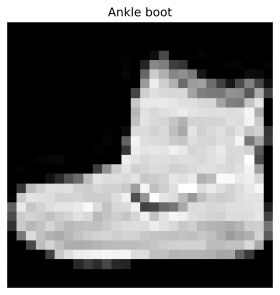

In [ ]:
labels = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

index = 0

print("Label:", data.train[1][index])
print("Class:", labels[data.train[1][index]])
print("Image shape:", data.train[0][index].shape)

print("\nFirst 5 × 5 pixel values:")
print(data.train[0][index][:5, :5])

import matplotlib.pyplot as plt

plt.imshow(data.train[0][index], cmap="gray")
plt.title(labels[data.train[1][index]])
plt.axis("off")
plt.show()

### Understanding the Output

From the output, we observe that:

- The **label** is stored as an integer (0–9).
- The **class name** provides a human-readable description of that label.
- The image has dimensions **28 × 28**, meaning it contains **784 pixels**.
- Each pixel stores an intensity value between **0 (black)** and **255 (white)**.

Notice that the first **5 × 5** pixel values are all **0**. This simply means that the upper-left corner of this image is completely black. Different regions of the image contain different pixel intensities, which together form the object shown below.

Although the computer stores the image as a matrix of numbers, visualization libraries such as Matplotlib convert those numbers into the image we recognize. During training, however, the neural network learns directly from the **pixel values**, not from the displayed image.

In [ ]:
print(data.train)
print(data.train[1])
print(data.train[1][0])

(array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ...,

## 2. Reading a Minibatch

During training, a neural network usually does not process the entire dataset at once. Instead, the data is divided into smaller groups called **minibatches**.

A minibatch contains:

- a group of images, represented by `X`, and
- the corresponding class labels, represented by `y`.

Using minibatches makes training more memory-efficient and allows the model to update its parameters repeatedly as it moves through the dataset.

The following method prepares the Fashion-MNIST data by:

- converting pixel values from integers to floating-point numbers,
- scaling pixel values from the range 0–255 to 0–1,
- adding a channel dimension for grayscale images,
- resizing the images when requested,
- grouping examples into minibatches, and
- shuffling the training data.

In [ ]:
@d2l.add_to_class(FashionMNIST)

def get_dataloader(self, train):
    data = self.train if train else self.val
    process = lambda X, y: (tf.expand_dims(X, axis=3) / 255,
                            tf.cast(y, dtype='int32'))
    resize_fn = lambda X, y: (tf.image.resize_with_pad(X, *self.resize), y)
    shuffle_buf = len(data[0]) if train else 1
    return tf.data.Dataset.from_tensor_slices(process(*data)).batch(
        self.batch_size).map(resize_fn).shuffle(shuffle_buf)

The following code retrieves one minibatch from the training data:




Here:

- `data.train_dataloader()` creates the training data loader.
- `iter(...)` creates an iterator that moves through the minibatches.
- `next(...)` returns the first minibatch.
- `X` contains the images.
- `y` contains the corresponding labels.

In [ ]:
X, y = next(iter(data.train_dataloader()))
print(X.shape, X.dtype, y.shape, y.dtype)

(64, 32, 32, 1) <dtype: 'float32'> (64,) <dtype: 'int32'>


The output is

```text
(64, 32, 32, 1) float32
(64,) int32
```

The image batch shape `(64, 32, 32, 1)` means:

- `64` images in the minibatch,
- each image has a height of `32` pixels,
- each image has a width of `32` pixels,
- each image has `1` grayscale channel.

The label shape `(64,)` means that the minibatch contains one numeric label for each of the 64 images.

The image values use the `float32` data type because neural networks perform calculations with floating-point values. The labels use `int32` because each label is stored as an integer from 0 to 9.

The default batch size is 64, so each minibatch contains 64 images and their corresponding labels.
Each image has one channel because Fashion-MNIST is a grayscale dataset. A color image would have three channels (RGB).

## 3. Visualizing the Dataset

After inspecting a single training example, we can now visualize several images from a minibatch.


The following code displays the first eight images from a minibatch together with their corresponding class labels.

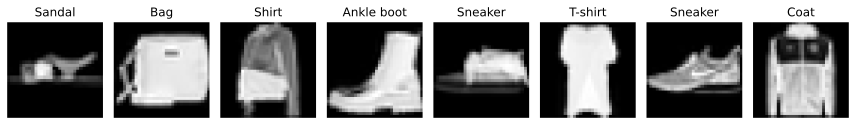

In [ ]:
batch = next(iter(data.train_dataloader()))
X, y = batch

labels = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 2))

for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X[i].numpy().squeeze(), cmap="gray")
    plt.title(labels[y[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

The figure shows eight examples from the Fashion-MNIST dataset.

Notice that:

- each image represents one clothing item,
- the images are grayscale,
- each image is labeled with its correct clothing category, and
- although the images are small (32 × 32 pixels after resizing), they contain enough information for a neural network to distinguish between different classes.

Visualizing the dataset is a good practice because it helps verify that the data has been loaded and labeled correctly before training begins.

## Summary

In this section, we introduced the **Fashion-MNIST** dataset, which will be used later.

We learned how to:

- load the Fashion-MNIST training and test datasets,
- inspect individual images and their labels,
- understand how images are represented as matrices of pixel values,
- organize the data into minibatches for efficient training, and
- visualize multiple images to become familiar with the dataset.

We are now ready to build our first image classification model using this dataset.